🎌 Otaku Engine: Anime Market Intelligence
Strategic Analysis of the Top 2500 Titles via Analytics Engineering

👨‍💻 Project Profile

Tech Stack: Python | DuckDB | dbt | Plotly

Data Source: MyAnimeList (MAL) via Jikan API

🎯 Executive Summary
This project is designed to bridge the gap between "popular" content and "high-quality" production. By transforming raw API data into a structured Star Schema using dbt, this report identifies market anomalies, studio consistency, and the emotional "Loyalty Funnel" of the global anime audience.

🏗️ Data Architecture
To ensure scalability (from 250 to 1,000+ records), the warehouse is built on three optimized Data Marts:

Performance & Gap Mart: Analyzes the "Value Gap" (Rank vs. Popularity).

Historical Evolution Mart: Tracks industry shifts and production booms over decades.

Studio Consistency Mart: Evaluates production houses by volume, quality, and volatility.

📊 Key Research Pillars
The Loyalty Funnel: Measuring "Conversion Rates" from casual viewers to dedicated fans.

The Quality Frontier: Identifying "Hidden Gems" that the algorithm often ignores.

Studio Benchmarking: Comparing the reliability of powerhouses like Madhouse and MAPPA.

1. Environment & Connection Setup
Context: We need to import the tools for data handling (pandas), the database engine (duckdb), and the visualization library (plotly). Then, we establish a persistent connection to your dbt-transformed warehouse so we can pull our "Gold Marts."

In [1]:
import duckdb
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

con = duckdb.connect('../data/mal_data.duckdb')

2. The Global Summary (KPIs)
Before going into specific studios or genres, we are going to define our current project dataset. This section extracts high-level metrics of the Top 2500 titles to establish a baseline for Quality (Score) and Scale (Reach). The current dataset has been extracted on March 3rd 2026.

In [2]:
# Extracting global benchmarks from fact table

queryText = """
    SELECT
        COUNT(anime_id) as total_titles,
        ROUND(AVG(score), 2) as avg_score,
        ROUND(AVG(members), 0) as avg_members,
        ROUND(AVG(scored_by), 0) as avg_voters,
        ROUND(100.0 * SUM(favorites) / NULLIF(SUM(members), 0), 2) as global_loyalty
    FROM fct_anime_stats
"""

global_stats = con.sql(queryText).df()

global_stats

,total_titles,avg_score,avg_members,avg_voters,global_loyalty
0,2500,7.85,278069.0,149280.0,1.58


3. Pillar 1: The Value Gap (Rank vs. Popularity)
This is a type of "Market Anomaly" analysis. We are looking for the discrepancy between a show's Score Rank (how much it is liked) and its Popularity Rank (how much it is seen).

- A large positive gap means a highly rated but under-watched.
- A large negative gap means the anime is popular but the score does not match its popularity.
- A small gap, positive or negative mean both stats match; the anime is "as good as it is popular".

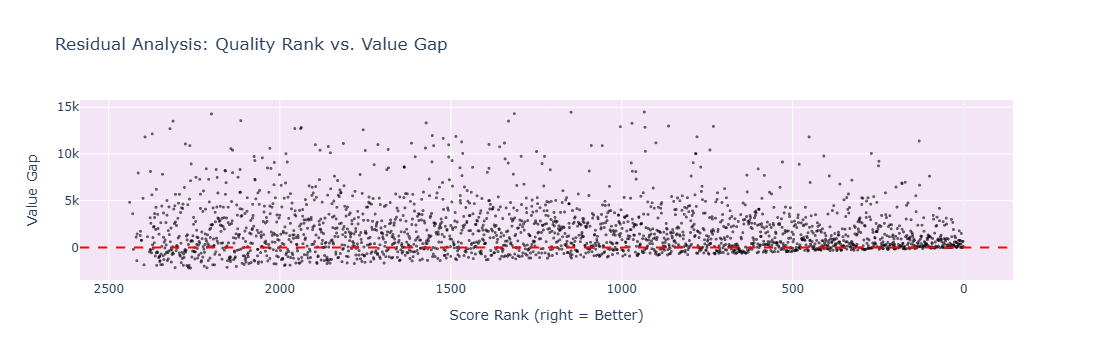

In [3]:
# Query: Calculating the Gap between Quality (Score Rank) and Reach (Popularity Rank)
# Logic: Gap = Popularity_Rank - Score_Rank 
query_gap = """
SELECT 
    a.title_default,
    s.score,
    s.members,
    s.popularity,
    s.rank,
    (s.popularity - s.rank) as value_gap
FROM fct_anime_stats s
JOIN dim_anime a ON s.anime_id = a.anime_id
ORDER BY value_gap DESC
"""

df_gap = con.sql(query_gap).df()

# Visualizing the Gap with a Scatter Plot
fig_residual = px.scatter(
    df_gap, 
    x="rank", 
    y="value_gap",
    hover_name="title_default",
    title="Residual Analysis: Quality Rank vs. Value Gap",
    template="plotly_white"
)

fig_residual.update_traces(marker=dict(color='black', size=3, opacity=0.6))

fig_residual.update_layout(
    plot_bgcolor='#F3E5F5', 
    xaxis=dict(gridcolor='white'),
    yaxis=dict(gridcolor='white')
)

# Adding the reference line at 0
fig_residual.add_hline(y=0, line_width=2, line_dash="dash", line_color="red")

# Reverse x axis so the highest quality (Rank 1) is on the right
fig_residual.update_xaxes(autorange="reversed", title="Score Rank (right = Better)")
fig_residual.update_yaxes(title="Value Gap")

fig_residual.show()

The graph shows some interesting numbers with some overview of the anime market of the top 2500.
- The fact that most of the points are above 0 shows that a good part of animes are over-ranked and underwatched.
- Likewise, it is clear there is a considerable amount of anime that have low correlation between their score ranking and their popularity ranking.
- Another noticeable fact is that the dots figuring out the top of the chart (10k+ gap) are mostly Chinese anime titles, showing how the members of MyAnimeList (mostly western) are unaware of good Chinese shows.

3.2 Extreme gap analysis: top 2500

To further investigate what titles stands out in the 3 categories specified, we are going to run a table with some strategic segments:
- The "hidden gems": titles with the largest positive gaps; highly rated compared to a rather little following
- The "overhyped": titles with the largest negative gaps; way more popular than its score would suggest
- The "balanced ones": lowest gap, meaning their score rankings follow their popularity

In [4]:
# Query: selecting our titles from the previous query
query_extremesGap = """
WITH ranked_gap AS (
    SELECT
        title_default,
        score,
        popularity,
        rank,
        value_gap
    FROM df_gap
)
(SELECT *, 'Hidden Gem' as category FROM ranked_gap ORDER BY value_gap DESC LIMIT 10)
UNION ALL
(SELECT *, 'Overhyped' as category FROM ranked_gap ORDER BY value_gap ASC LIMIT 10)
UNION ALL
(SELECT *, 'Balanced' as category FROM ranked_gap ORDER BY ABS(value_gap) ASC LIMIT 10)
"""

df_extremeGaps = con.sql(query_extremesGap).df()

df_extremeGaps

,title_default,score,popularity,rank,value_gap,category
0,You Shou Yan 3rd Season,7.88,15421,934,14487,Hidden Gem
1,You Shou Yan 4th Season,7.79,15608,1148,14460,Hidden Gem
2,Guangyin Zhi Wai,7.72,15620,1314,14306,Hidden Gem
3,Shixiong A Shixiong 3rd Season,7.47,16480,2200,14280,Hidden Gem
4,Langlang Shan Xiao Yaoguai,7.50,15675,2114,13561,Hidden Gem
5,You Shou Yan 2nd Season,7.73,14842,1331,13511,Hidden Gem
6,Shenguo Zhi Shang,7.44,15821,2312,13509,Hidden Gem
7,Dadao Chaotian,7.63,14893,1572,13321,Hidden Gem
8,Wu Dong Qian Kun 6th Season,7.87,14246,970,13276,Hidden Gem
9,Shen Yin Wangzuo Movie: Yi Lai Ke Si Chuanqi,7.91,13848,863,12985,Hidden Gem


The table gives us some very interesting views of the anime schedule and brings forward some conclusions:
- The "hidden gems" are, as suggested, mostly Chinese shows that the western audience is unaware of. While their scores are not particularly high, they are mostly higherly rated than the overhyped category. Noticeably, no anime here figures anywhere near the two-digit score rankings.
- The overhyped tells the story of gateway animes. Show that are rather popular and have been watched by many for any reason, but have a general consesus that their quality is not there. Here we see that most figure the top 100 in popularity but score ranks are all near 2000.
- The balanced category shows us some renowed masterpieces that received not only comercial success but critical acclaim. 

3.3 A Zoom in the Gaps
In the universe of animes the top 2500 is a large number. To investigate the actual heavy weights we are going to review the same results for the top 250 (top 10%) of animes to visualize the behavior of both the scatter plot and the table.

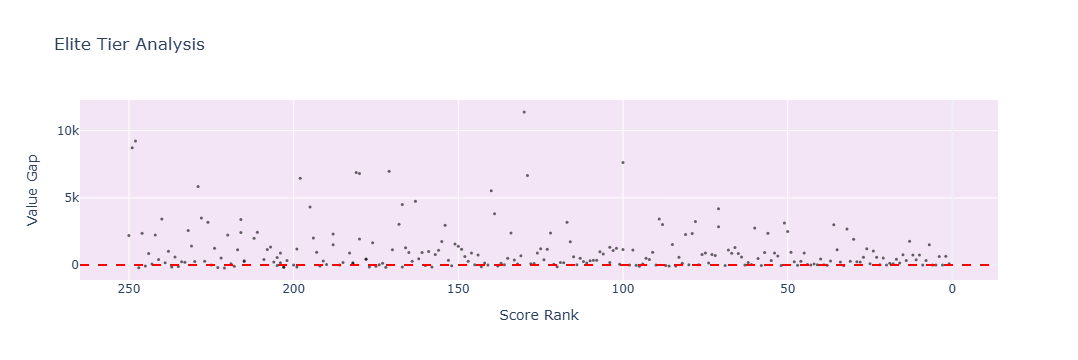

,title_default,score,members,popularity,rank,value_gap,category
0,Fanren Xiu Xian Zhuan 4th Season,8.55,2716,11517,130,11387,High positive gap
1,Tunshi Xingkong 3rd Season,8.37,4957,9470,248,9222,High positive gap
2,Tunshi Xingkong 4th Season,8.37,5742,8979,249,8730,High positive gap
3,Luo Xiaohei Zhanji 2,8.61,8328,7722,100,7622,High positive gap
4,Nezha Zhi Mo Tong Nao Hai,8.48,10180,7143,171,6972,High positive gap
5,Xian Ni,8.46,10417,7069,181,6888,High positive gap
6,Tian Guan Cifu Short Films,8.46,10636,7002,180,6822,High positive gap
7,Doupo Cangqiong: San Nian Zhi Yue,8.55,11456,6786,129,6657,High positive gap
8,Doupo Cangqiong: Nian Fan,8.43,12008,6655,198,6457,High positive gap
9,Ramayana: The Legend of Prince Rama,8.39,15100,6070,229,5841,High positive gap


In [5]:
# Select the top of our universe
df_top_percent = df_gap[df_gap['rank'] <= 250].copy()

query_top_percent = """
WITH elite_gap AS (
    SELECT * FROM df_top_percent
)
(SELECT *, 'High positive gap' as category FROM df_top_percent ORDER BY value_gap DESC LIMIT 10)
UNION ALL
(SELECT *, 'High negative gap' as category FROM df_top_percent ORDER BY value_gap ASC LIMIT 10)
UNION ALL
(SELECT *, 'Balanced' as category FROM df_top_percent ORDER BY ABS(value_gap) ASC LIMIT 10)
"""

# Perform the query
df_elite_table = con.sql(query_top_percent).df()

# We are also doing the same scatter plot graph using this new selection of data.
fig_elite = px.scatter(
    df_top_percent, 
    x="rank", 
    y="value_gap",
    hover_name="title_default",
    title="Elite Tier Analysis",
    template="plotly_white"
)

fig_elite.update_traces(marker=dict(color='black', size=3, opacity=0.6))

fig_elite.update_layout(
    plot_bgcolor='#F3E5F5', 
    xaxis=dict(gridcolor='white'),
    yaxis=dict(gridcolor='white')
)

fig_elite.add_hline(y=0, line_width=2, line_dash="dash", line_color="red")

fig_elite.update_xaxes(autorange="reversed", title="Score Rank")
fig_elite.update_yaxes(title="Value Gap")

fig_elite.show()
df_elite_table

Our zoomed analysis only makes the initial points stronger. 
- The "Chinese Bias" remains even in the score elite. Decently rated titles, some even with score that rival proven animes like Kimetsu no Yaiba. Although the fact that pulling the number of members revealed some further details; MAL's score is not weighted, therefore, Fanren Xiu Xian Zhuan's 2710 members (as well as these high gap titles) drive its score up: the only people in the western-ish MAL community that know this title are fans. Meanwhile Kimetsu no Yaiba figures as the elite's "overhyped", which is a unfair logic as it is currently the most successful modern series. This brings the question of applying weighted scores and see how the dataset behaves.
- As stated, the overhyped group now seems as a highly unfair title when comparing within the elite. This group simply brings up the previous conclusion stronger: Gateway anime. The titles on the elite are all beloved shows with quality way above the previous list, but they show the same trend of being more popular than highly scored. The titles show the idea clearly: accessible shows that appeal to the masses.
- The balanced category remains stable: shows that justify their following with a comparable quality.

The conclusion here is that the Rank Gap value can bring up some very interesting conclusions regarding the Anime Market in General. It can divide the titles in three separate groups. But it is noticeable that the lack of a weighted score may skewer the results in favor of niche titles, which have a very small but loyal community.

3.4 The Rank Gap, but structural:

As a last analysis point, we are going to investigate if there is any correlation between Genre/Media Type/Demographics and the Rank Gap. It was shown the Rank Gap can provide valuable insights in the anime market, and Genre/Demographics as a core attribute of animes may reveal more about how the Rank Gab behaves when compared through their lenses.

In [6]:
# Average gap by Media Type (Tv, movies, specials etc)

query_type = """
SELECT
    media_type,
    COUNT(*) as count,
    ROUND(AVG(popularity - rank), 0) as avg_gap
FROM fct_anime_stats s JOIN dim_anime a ON s.anime_id = a.anime_id

GROUP BY 1 
HAVING count > 5
ORDER BY avg_gap DESC
"""

# Average gap by Genre
query_genre = """
SELECT
    g.genre_name as genre,
    COUNT(s.anime_id) as count,
    ROUND(AVG(s.popularity - s.rank), 0) as avg_gap
FROM fct_anime_stats s 
JOIN dim_genres g ON s.anime_id = g.anime_id

GROUP BY 1 
HAVING count > 5
ORDER BY avg_gap DESC
"""

# Average gap by Demographics
query_demo = """
SELECT
    d.demographic,
    COUNT(s.anime_id) as count,
    ROUND(AVG(s.popularity - s.rank), 0) as avg_gap
FROM fct_anime_stats s 
JOIN dim_demographics d ON s.anime_id = d.anime_id

GROUP BY 1 
HAVING count > 5
ORDER BY avg_gap DESC
"""

df_type = con.sql(query_type).df()
df_demo = con.sql(query_demo).df()
df_genre = con.sql(query_genre).df()

display(df_type)
display(df_demo)
display(df_genre)

,media_type,count,avg_gap
0,ONA,270,5768.0
1,Movie,526,2231.0
2,TV Special,64,2221.0
3,OVA,240,2114.0
4,Special,120,2076.0
5,TV,1216,631.0
6,PV,11,NaN
7,Music,55,NaN


,demographic,count,avg_gap
0,Kids,39,3894.0
1,Unspecified,1337,2259.0
2,Josei,30,1759.0
3,Seinen,294,1333.0
4,Shoujo,121,1307.0
5,Shounen,696,1194.0


,genre,count,avg_gap
0,Unspecified,74,4542.0
1,Boys Love,35,2676.0
2,Adventure,578,2560.0
3,Fantasy,625,2287.0
4,Slice of Life,161,2194.0
5,Sci-Fi,381,2035.0
6,Girls Love,25,2008.0
7,Action,854,1993.0
8,Sports,151,1721.0
9,Comedy,755,1601.0


The tables gives us some interesting insights regarding these attributes. It's worth to recap that lower values just mean titles are "as highly scored as popular".

- Media Type: The average gap being the smallest in the TV category shows the following on the regular TV series outshines the Movie/Special entries in popularity. It is somewhat expected, as it should be common for most people to watch add and score One Piece, but even though they probably will watch Movies or Specials they might not add or scoring them. Inflating the score, as only the more loyal fans will be through with their list/scoring. ONAs are a very niche media type where if one does know about a title, they are most likely either fans of the series or a potential fan.
- Demographics: Here we see Unspecified the title count. As Jikan is fed by MAL which in turn is fed by their users, it allows for certain titles to have empty attributes. While initially the instinct is to ignore it, this value tells a story: Their the second most "unpopular" group, therefore these should encompass a niche where people don't even bother to fill the anime page. The Kids position implies that MAL users may simply not watch shows aimed at children, even when those shows are critically acclaimed. The drop in gap on the rest of the demographics may show that "easier" to watch content (Shounen/Shojo) is more accessible, therefore being more balanced than their more adult/complex peers.
- Genre: This part is rather interesting, as it shows the big genres (Action, Adventure, Fantasy) have all high gaps. The sheer volume of this type of series may just explain this behavior; outside of the most popular shows, there's plenty of good unknown shows. The most niche types demonstrate how these followers are rather completionists; once a good show pops up, it will be watched by its fans. The high gap on the Unspecified may also relate to the aforementioned Chinese ONAs titles.

A note on the NaN values; The Hentai for Genres and PV/Music for Media Type are often forced a NaN rank value so that these titles remain outside the official list for understandable reasons.

4. Pillar 2: Historical Evolution

We now use these titles release year to investigate the quality (score) evolution throughout the years, as it is a known fact that the anime industry has nothing but grown for the past 40 years, does this grow translate into more quality output?

The first analyis will compare the average score and volume of animes per year.

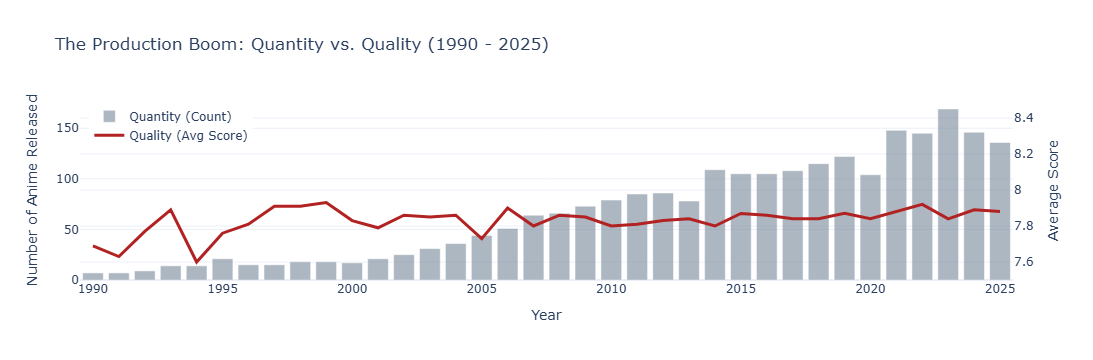

In [7]:
# Querying volume and average score by year
query_evolution = """
SELECT 
    a.release_year,
    COUNT(a.anime_id) as anime_count,
    ROUND(AVG(s.score), 2) as avg_score
FROM dim_anime a
JOIN fct_anime_stats s ON a.anime_id = s.anime_id
WHERE a.release_year >= 1990 
  AND a.release_year < 2026
  AND s.score IS NOT NULL
GROUP BY 1
ORDER BY 1
"""

df_evolution = con.sql(query_evolution).df()

# Importing dual axis chart
import plotly.graph_objects as go

fig_evo = go.Figure()

# Using a bar for volume
fig_evo.add_trace(go.Bar(
    x=df_evolution['release_year'],
    y=df_evolution['anime_count'],
    name='Quantity (Count)',
    marker_color='lightslategrey',
    opacity=0.6
))

# A line for score
fig_evo.add_trace(go.Scatter(
    x=df_evolution['release_year'],
    y=df_evolution['avg_score'],
    name='Quality (Avg Score)',
    yaxis='y2',
    line=dict(color='firebrick', width=3)
))

# Layout for dual axis
fig_evo.update_layout(
    title="The Production Boom: Quantity vs. Quality (1990 - 2025)",
    xaxis=dict(title="Year"),
    yaxis=dict(title="Number of Anime Released"),
    yaxis2=dict(title="Average Score", overlaying='y', side='right', range=[7.5, 8.5]),
    template="plotly_white",
    legend=dict(x=0.01, y=0.99)
)

fig_evo.show()

This graph shows the increases in the anime industry through the last 35 years. It is clear to notice how the new technology factors compound over the years (internet, streaming) along with the slow but rather sure breaking of the bubble; Anime is no longer a niche entertainment type.

5. Pillar 3: Studio results

In [8]:
query_studio_performance = """
SELECT 
    st.studio,
    COUNT(s.anime_id) as title_count,
    ROUND(AVG(s.score), 2) as avg_score,
    ROUND(AVG(s.popularity), 0) as avg_popularity_rank,
    ROUND(AVG(s.popularity - s.rank), 0) as avg_value_gap
FROM fct_anime_stats s
JOIN dim_studios st ON s.anime_id = st.anime_id
WHERE s.rank IS NOT NULL 
  AND s.popularity IS NOT NULL
GROUP BY 1
HAVING title_count >= 10
ORDER BY avg_score DESC
LIMIT 20
"""

df_studios = con.sql(query_studio_performance).df()

display(df_studios)

,studio,title_count,avg_score,avg_popularity_rank,avg_value_gap
0,Studio Ghibli,18,8.13,690.0,-1.0
1,Shuka,17,8.11,2539.0,1809.0
2,Kinema Citrus,14,8.10,1880.0,1096.0
3,ufotable,28,8.09,1059.0,236.0
4,SynergySP,11,8.08,2899.0,2155.0
5,CygamesPictures,10,8.06,3444.0,2625.0
6,Bandai Namco Pictures,24,8.06,3213.0,2201.0
7,MAPPA,48,8.04,1846.0,922.0
8,Wit Studio,37,8.02,1774.0,846.0
9,Tokyo Movie Shinsha,12,8.02,3006.0,2144.0


This table reveals some sort of prestige hierarchy in the anime industry. Studio Ghibli stands on top as the perfect market equilibrium, with a value gap of -1.0 indicating that their popularity exactly matches their elite quality. On the other end, high-quality but niche studios like Shuka and Sparkly Key Animation Studio (responsible for the the high-score, low-popularity Chinese ONA market) show massive value gaps of +1,809 and +8,335 respectively, proving that even with an 8.0+ average score, they remain "undiscovered". Meanwhile, big studios like ufotable, Bones, and White Fox maintain very low or negative gaps, confirming that their brand names weight on the discovery. Whenever they release a high-quality title, the market responds, leaving little room for a hidden gems to exist under their banner.

6. Pillar 4

We further analyse the loyalty and interactivy (Members/Favorites/Voters) throughout the dataset.

In [9]:
query_loyalty = """
SELECT
    media_type,
    COUNT(*) AS count,
    AVG((CAST(s.scored_by AS FLOAT) / s.members) * 100.0) as scored_by_ratio,
    AVG((CAST(s.favorites AS FLOAT) / s.members) * 100.0) as favorites_ratio
FROM fct_anime_stats s
JOIN dim_anime a ON s.anime_id = a.anime_id
WHERE s.members > 10000
GROUP BY 1
HAVING count > 5
ORDER BY favorites_ratio DESC
"""

df_loyalty = con.sql(query_loyalty).df()

df_loyalty


,media_type,count,scored_by_ratio,favorites_ratio
0,TV,1199,45.379621,1.123723
1,Music,16,54.025593,0.874472
2,ONA,148,45.058142,0.803153
3,Movie,483,47.100690,0.532937
4,OVA,224,46.808069,0.519822
5,TV Special,60,51.454688,0.319232
6,Special,115,50.159164,0.157635


These results prove that TV series are the absolute king of engagement, pulling a 1.12% advocacy rate that doubles almost every other format. While people are happy to finish and "score" movies and OVAs (around 47% completion), they rarely stick around to label them as a "Favorite" compared to the long-term bonding that happens over a 12 or 24-episode TV run. It basically shows that the industry "snack" content like Music videos and Specials gets consumed but has almost zero emotional footprint, while the TV format is where the real "super-fans" are born.

In [10]:
queryText = """
SELECT
    a.title_default as anime,
    a.media_type,
    s.score,
    s.members,
    ((CAST(s.scored_by AS FLOAT) / s.members) * 100.0) as scored_by_ratio,
    ((CAST(s.favorites AS FLOAT) / s.members) * 100.0) as favorites_ratio
FROM fct_anime_stats s
JOIN dim_anime a ON a.anime_id = s.anime_id
WHERE s.members > 10000
ORDER BY s.members DESC
"""

df_anime_loyalty = con.sql(queryText).df()

df_anime_loyalty.head(20)

,anime,media_type,score,members,scored_by_ratio,favorites_ratio
0,Shingeki no Kyojin,TV,8.57,4313630,70.402931,4.340590
1,Death Note,TV,8.62,4253537,69.975174,4.340528
2,Fullmetal Alchemist: Brotherhood,TV,9.11,3643577,62.821453,6.607738
3,One Punch Man,TV,8.48,3489831,68.901421,1.900980
4,Kimetsu no Yaiba,TV,8.41,3405834,68.643097,2.777117
5,Boku no Hero Academia,TV,7.83,3273527,67.824188,1.679534
6,Hunter x Hunter (2011),TV,9.03,3149760,62.114353,7.229217
7,Naruto,TV,8.02,3087911,68.764549,2.778448
8,Tokyo Ghoul,TV,7.79,3031042,65.607109,1.742140
9,Kimi no Na wa.,Movie,8.83,2997307,68.889206,3.170680


This table provides the ultimate proof of the "TV Bonding Effect." While heavy hitters like Kimi no Na wa. (Your Name) and Koe no Katachi (A Silent Voice) have incredible scores and high completion rates (~69% completion), their "Advocacy" (Favorites) sits at 3.1% and 3.6%. Compare that to long-running TV titans: One Piece has a massive 9.4% advocacy rate, and Hunter x Hunter (2011) hits 7.2%. This confirms that "Members" don't just watch these long-form series; they integrate them into their identity in a way that 2-hour movies, regardless of how "perfect" they are, rarely achieve.

Wrap-Up: The Otaku Engine Analysis
This notebook successfully transitions from a raw data ingestion phase into a structured Four-Pillar Analytical Framework. By moving beyond simple "Top 10" lists, we identified the structural inefficiencies of the anime market—specifically the Value Gap affecting niche media types like ONAs and the high conversion-to-fan efficiency of the TV format. While the findings highlight the "industrialization" and quality stability of the modern production boom, the underlying dbt-powered architecture ensures that these insights are based on a scalable, cleaned star schema rather than just raw API noise. This project stands as a bridge between Analytics Engineering (the pipeline) and Data Science (the behavioral insights), providing a data-driven map for navigating the massive expansion of the anime industry.